# AI Essays Detector

---

### Project Overview
Our mini-project is creating an AI-generated essay detector that classifies the probability of whether a given essay was written by a human or generated by AI.

The dataset used is the `AI_Human.csv` dataset from Kaggle, containing labelled text samples:
- `generated = 0.0` - Human-written
- `generated = 1.0` - AI-generated

Link to the dataset: <a>https://www.kaggle.com/datasets/muqaddasejaz/ai-vs-human-text-dataset</a>

### Problem Statement
> *How to distinguish between AI-generated essays and human-written essays using a Machine Learning model?*

We focus our detector specifically on essays and not text in general because our dataset consists of mostly academic essays and journals.

This is a binary classification problem.

---

### Team Contributions
| Member | Contributions |
|--------|------|
| **Azman** | Data Prep & Cleaning: import libraries, create/visualise dataframe, balance dataset, text cleaning and demo code |
| **Elyaas** | EDA: engineer all stylometric features, statistics tables, KDE plots and correlation heatmap |
| **Aqil** | Modelling: train/test split, TF-IDF vectorisation, feature fusion using HStack, logistic regression training, website creation and deployment |
| **Eason** | Evaluation & Visualisation: confusion matrix, top-15 feature weight plots, S-curve and logistic regression equation display |

---
## Part 1: Data Preparation and Cleaning

These are the steps we took to prepare and clean the data:
1. Importing all required Python libraries
2. Loading the dataset into a Pandas DataFrame
3. Visualising the raw class distribution
4. Balancing the dataset (equal class sizes to prevent model bias)
5. Cleaning the raw text to remove noise before feature extraction

### 1.1 Import Libraries

We import the full stack needed across all sections of the project:
- **`pandas` / `numpy`** for data manipulation and numerical operations
- **`matplotlib` / `seaborn`** for all visualisations (count plots, KDE plots, heatmaps, bar charts)
- **`re`** for regular expressions for text cleaning and stylometric feature calculation
- **`scipy.sparse`** for sparse matrix operations needed to fuse the TF-IDF matrix with stylometric features
- **`sklearn`** modules:
  - `StandardScaler` which normalises stylometric feature values
  - `train_test_split` which splits data for training and testing
  - `TfidfVectorizer` which converts text to numerical TF-IDF vectors
  - `LogisticRegression` which is the binary classifier
  - `accuracy_score`, `classification_report`, `confusion_matrix` which are evaluation tools

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import re
import scipy.sparse as sp
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sb.set()

### 1.2 Load & Inspect the Dataset

We load `AI_Human.csv` and sample 20 random rows to see the structure of the dataset.

Columns:
- `text` is the essay content
- `generated` is the label (0.0 = Human, 1.0 = AI)

In [2]:
df = pd.read_csv("AI_Human.csv")
df.sample(20)

,text,generated
112918,There is no doubt that the number of cars in u...,1.0
344303,"Yes, I can identify with Winston Churchill an...",1.0
109503,The use of electronic dictionaries (Dictionari...,1.0
169238,The author of this passage talks about explori...,0.0
197784,Limiting car usage has many advantages. For ex...,0.0
299729,The Importance of Keeping the Electoral Colleg...,1.0
213375,Could you imagine a life without a car? Well i...,0.0
372409,"Throughout history, people of various backgrou...",1.0
445953,"Dear Senator,\n\nDon't you think that everyone...",0.0
97479,"In the past two decades, we have seen a massiv...",1.0


### 1.3 Visualise Raw Class Distribution

Before balancing, we plot how many human vs AI samples exist in the raw dataset. This step identifies class imbalance, where one class dominates, which can bias a trained model to favour the majority class and produce misleadingly high accuracy scores.

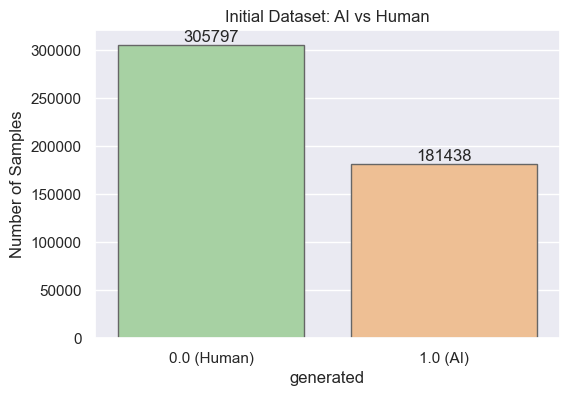

In [3]:
plt.figure(figsize=(6, 4))

custom_colors = {0.0: '#A1D99B', 1.0: '#FDBE85'}

# Assign the plot to the 'ax' variable
ax = sb.countplot(data=df, x='generated', hue='generated', palette=custom_colors, edgecolor="0.4", legend=False)

plt.title('Initial Dataset: AI vs Human')
plt.xticks(ticks=[0, 1], labels=['0.0 (Human)', '1.0 (AI)'])
plt.ylabel('Number of Samples')

# Loop through the containers and add the labels
for container in ax.containers:
    ax.bar_label(container)

plt.show()

We can see there are 305797 essays for Human while 181438 essays for AI generated. We have to balance this to ensure accuracy of the training model later.

### 1.4 Balance Dataset & Clean Text

**Why balance?**  
If there are significantly more AI samples than human (or vice versa), the model will be biased when we do the `train_test_split` later. We downsample the majority class to `min_count` which is 181438 rows so both classes have equal representation. So there will be 181438 essays for both AI and Human generated.

**Text Cleaning (`clean_text`):**  
The function standardises raw text before any feature extraction:
- Converts everything to lowercase which removes case sensitivity from word comparisons (e.g. Essays vs essay are to be taken as the same word)
- Uses `re.sub` to strip non-essential characters by keeping only letters, spaces, core punctuation (`,.'-`), newlines, digits. Removes HTML entities, special Unicode, etc.

The cleaned text is stored in a new column `cleaned_text`.

In [4]:
# Balance the dataset
df_human = df[df['generated'] == 0]
df_ai = df[df['generated'] == 1]

min_count = min(len(df_human), len(df_ai))

df_human_balanced = df_human.sample(n=min_count)
df_ai_balanced = df_ai.sample(n=min_count)

df_balanced = pd.concat([df_human_balanced, df_ai_balanced]).sample(frac=1).reset_index(drop=True)

# Text Cleaning Function
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower() 
    text = re.sub(r'[^a-z\s,.\'\-\*\+\n!?0-9]', '', text) 
    return text

print("cleaning text")
df_balanced['cleaned_text'] = df_balanced['text'].apply(clean_text)
print("done")

cleaning text
done


### 1.5 Verify Balanced Class Distribution

We re-plot the class distribution after balancing to confirm equal sample counts.

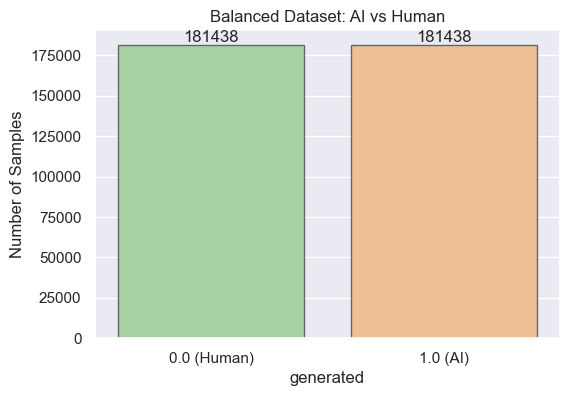

In [5]:
plt.figure(figsize=(6, 4))

custom_colors = {0.0: '#A1D99B', 1.0: '#FDBE85'}

# Assign the plot to the 'ax' variable
ax = sb.countplot(data=df_balanced, x='generated', hue='generated', palette=custom_colors, edgecolor="0.4", legend=False)

plt.title('Balanced Dataset: AI vs Human')
plt.xticks(ticks=[0, 1], labels=['0.0 (Human)', '1.0 (AI)'])
plt.ylabel('Number of Samples')

# Loop through the containers and add the labels
for container in ax.containers:
    ax.bar_label(container)

plt.show()

---
## Part 2: Exploratory Data Analysis (EDA) & Stylometric Feature Engineering

This section is the core EDA contribution. The goal is to understand how AI and human writing differ statistically before building the classifier.

We engineered 6 custom stylometric features which are quantitative properties of writing style. The underlying hypothesis we had was that AI-generated text exhibits more uniform, structured prose compared to the natural variability of human writing. We came up with these features by researching on the internet for some ways to differentiate between AI and Human text. We found 6 features we thought might be the most effective for the context of our dataset.

We mainly utilised these two sources:

https://dl.acm.org/doi/10.1145/3703323.3703712

https://www.youtube.com/watch?v=6-StVJqezeA

### 2.1 Stylometric Feature Engineering

Each of the 6 features captures a different dimension of writing style. All are computed from the `cleaned_text` column using `re` (regex) and `numpy`.

| Feature | What it measures | Expected AI vs Human difference |
|---------|-----------------|----------------------------------|
| **Burstiness** | Standard deviation of sentence lengths (in words) | AI tends toward uniform sentence lengths → lower burstiness |
| **Comma Density** | Commas per 100 words | AI often uses more complex comma-separated clauses |
| **Pronoun Density** | First-person pronouns (I, me, my…) per 100 words | Human writing tends to be more personal → higher density |
| **Contraction Density** | Contractions (e.g. "don't", "it's") per 100 words | Human writing is more informal → more contractions |
| **Repeated Phrase Density** | Repeated 3-word trigrams per 100 trigrams | AI may repeat structural phrase patterns more often |
| **Sentence Start Repetition** | Repeated first words across sentences | AI essays sometimes begin many sentences with the same word |


##### **Disclaimer:** This cell **might take a few minutes** (5-7 minutes) to complete running due to having 6 stylometric feature generation functions and each function running through a very large dataset from the start to the end. Total of 6 times traversing through the huge dataset.

In [6]:
def get_burstiness(text):
    if not isinstance(text, str) or len(text.strip()) == 0: return 0
    sentences = re.split(r'[.!?]+', text)
    lengths = [len(s.split()) for s in sentences if len(s.strip()) > 0]
    return np.std(lengths) if len(lengths) > 0 else 0

def get_comma_density(text):
    if not isinstance(text, str) or len(text.strip()) == 0: return 0
    words = len(text.split())
    if words == 0: return 0
    return (text.count(',') / words) * 100

def get_personal_pronoun_density(text):
    if not isinstance(text, str) or len(text.strip()) == 0: return 0
    words = re.findall(r'\b[a-z]+\b', text)
    if len(words) == 0: return 0
    pronouns = {'i', 'me', 'my', 'mine', 'myself', 'we', 'us', 'our', 'ourselves'}
    count = sum(1 for w in words if w in pronouns)
    return (count / len(words)) * 100

def get_contraction_density(text):
    if not isinstance(text, str) or len(text.strip()) == 0: return 0
    words = len(re.findall(r'\b[a-z]+\b', text))
    if words == 0: return 0
    contractions = len(re.findall(r"[a-z]+'[a-z]+", text))
    return (contractions / words) * 100

def get_repeated_phrase_density(text):
    if not isinstance(text, str) or len(text.strip()) == 0: return 0
    words = re.findall(r'\b[a-z]+\b', text)
    if len(words) < 3: return 0
    trigrams = [' '.join(words[i:i+3]) for i in range(len(words)-2)]
    if len(trigrams) == 0: return 0
    from collections import Counter
    counts = Counter(trigrams)
    repeated = sum(c - 1 for c in counts.values() if c > 1)
    return (repeated / len(trigrams)) * 100

def get_sentence_start_repetition(text):
    if not isinstance(text, str) or len(text.strip()) == 0: return 0
    sentences = re.split(r'[.!?]+', text)
    starts = []
    for s in sentences:
        words = re.findall(r'\b[a-z]+\b', s.strip())
        if words:
            starts.append(words[0])
    if len(starts) < 2: return 0
    from collections import Counter
    counts = Counter(starts)
    repeated = sum(c - 1 for c in counts.values() if c > 1)
    return (repeated / len(starts)) * 100

print("calculating stylometric features")
df_balanced['burstiness'] = df_balanced['cleaned_text'].apply(get_burstiness)
df_balanced['comma_density'] = df_balanced['cleaned_text'].apply(get_comma_density)
df_balanced['pronoun_density'] = df_balanced['cleaned_text'].apply(get_personal_pronoun_density)
df_balanced['contraction_density'] = df_balanced['cleaned_text'].apply(get_contraction_density)
df_balanced['repeated_phrase_density'] = df_balanced['cleaned_text'].apply(get_repeated_phrase_density)
df_balanced['sentence_start_repetition'] = df_balanced['cleaned_text'].apply(get_sentence_start_repetition)
print("done")

calculating stylometric features
done


### 2.2 .describe()

For each of the 6 features, we display a grouped summary table (`describe()`) split by class label (Human=0, AI=1). This gives us:
- **Mean / median**
- **Standard deviation**
- **Min / max / percentiles**

This to verify that the engineered features exhibit meaningful differences between AI and human text.

In [7]:
features = ['burstiness', 'comma_density', 'pronoun_density', 'contraction_density', 'repeated_phrase_density', 'sentence_start_repetition']

for feature in features:
    display(df_balanced.groupby('generated')[[feature]].describe().T)

generated                   0.0            1.0
burstiness count  181438.000000  181438.000000
           mean        9.751910       6.586562
           std         6.773784       2.351067
           min         0.000000       0.000000
           25%         6.696169       5.123442
           50%         8.419575       6.184658
           75%        10.817865       7.550385
           max       493.500000      51.192447

generated                      0.0            1.0
comma_density count  181438.000000  181438.000000
              mean        3.606255       5.920085
              std         1.947365       2.391631
              min         0.000000       0.000000
              25%         2.173913       4.452055
              50%         3.457447       5.609756
              75%         4.867257       6.985294
              max        15.887850      36.518771

generated                        0.0            1.0
pronoun_density count  181438.000000  181438.000000
                mean        2.045556       2.135404
                std         2.160207       2.781600
                min         0.000000       0.000000
                25%         0.469484       0.267380
                50%         1.395349       1.045296
                75%         2.923977       2.702703
                max        20.945946      16.800000

generated                            0.0            1.0
contraction_density count  181438.000000  181438.000000
                    mean        1.205754       0.966653
                    std         1.026298       1.643612
                    min         0.000000       0.000000
                    25%         0.440529       0.000000
                    50%         0.979192       0.316456
                    75%         1.740506       1.007557
                    max        10.119048      11.450382

generated                                0.0            1.0
repeated_phrase_density count  181438.000000  181438.000000
                        mean        5.680904       9.942294
                        std         4.825663       7.946060
                        min         0.000000       0.000000
                        25%         2.543353       3.664921
                        50%         4.464286       8.309456
                        75%         7.357860      14.446953
                        max        91.656734      97.570850

generated                                  0.0            1.0
sentence_start_repetition count  181438.000000  181438.000000
                          mean       29.343408      29.246357
                          std        13.960414      14.945300
                          min         0.000000       0.000000
                          25%        20.000000      18.181818
                          50%        29.411765      30.000000
                          75%        38.709677      40.000000
                          max        91.666667      90.909091

### 2.3 Kernel Density Estimate Plots

KDE plots show the **probability distribution** of each feature, separately for human (green) and AI (orange) text. Unlike histograms, KDE curves are smooth and easier to visually compare.

**How to read them:**
- **Well-separated peaks** means that the feature clearly distinguishes AI from human which indicates it being a strong predictor
- **Heavy overlap** is less effective of features to differentiate between AI and Human text.

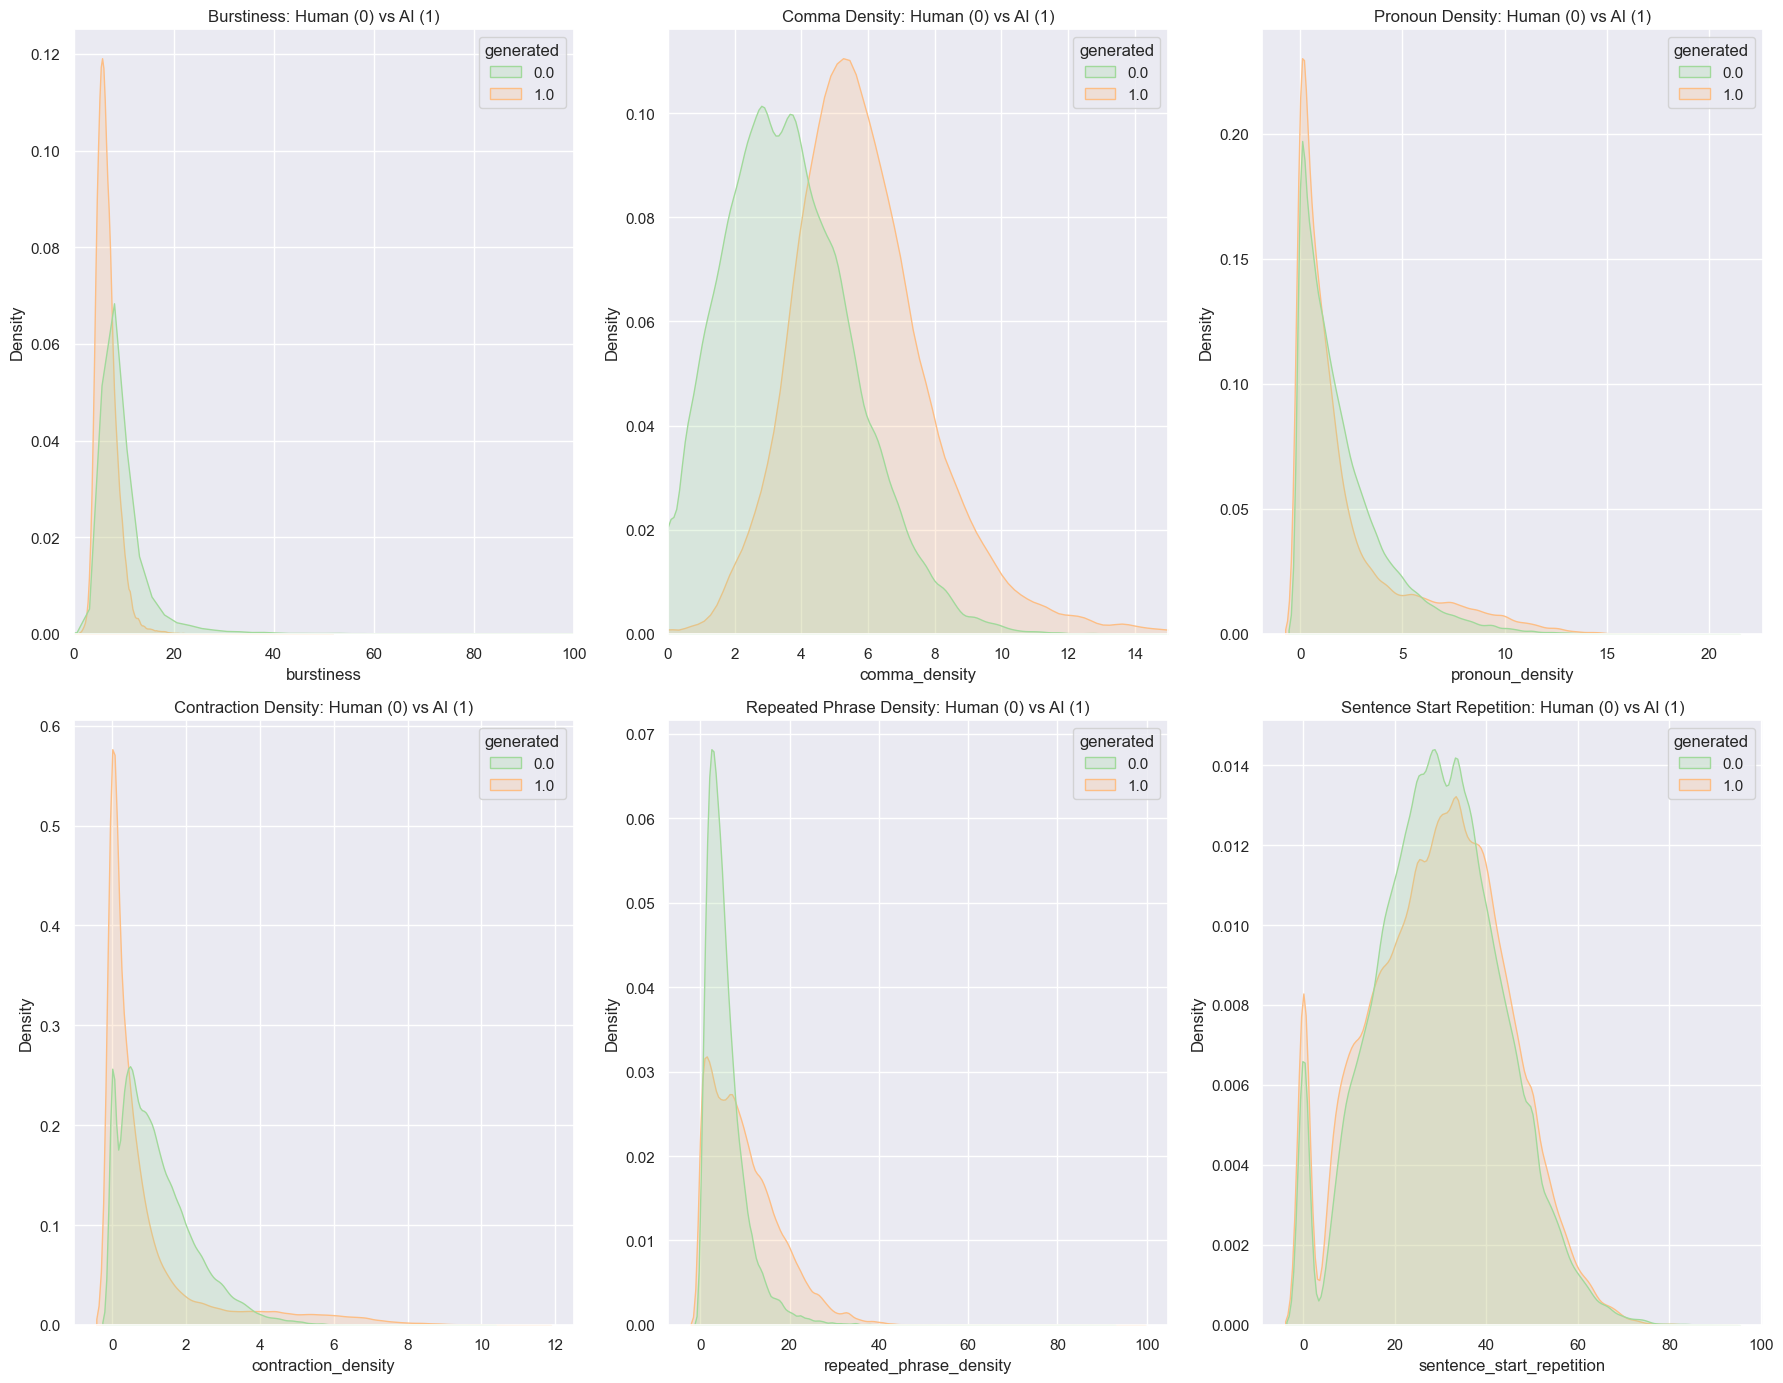

In [14]:
palette = {0.0: '#A1D99B', 1.0: '#FDBE85'}

fig, axes = plt.subplots(2, 3, figsize=(18, 14))

sb.kdeplot(data=df_balanced, x='burstiness', hue='generated', fill=True, palette=palette, ax=axes[0][0])
axes[0][0].set_title('Burstiness: Human (0) vs AI (1)')
axes[0][0].set_xlim(0, 100)

sb.kdeplot(data=df_balanced, x='comma_density', hue='generated', fill=True, palette=palette, ax=axes[0][1])
axes[0][1].set_title('Comma Density: Human (0) vs AI (1)')
axes[0][1].set_xlim(0, 15)

sb.kdeplot(data=df_balanced, x='pronoun_density', hue='generated', fill=True, palette=palette, ax=axes[0][2])
axes[0][2].set_title('Pronoun Density: Human (0) vs AI (1)')

sb.kdeplot(data=df_balanced, x='contraction_density', hue='generated', fill=True, palette=palette, ax=axes[1][0])
axes[1][0].set_title('Contraction Density: Human (0) vs AI (1)')

sb.kdeplot(data=df_balanced, x='repeated_phrase_density', hue='generated', fill=True, palette=palette, ax=axes[1][1])
axes[1][1].set_title('Repeated Phrase Density: Human (0) vs AI (1)')

sb.kdeplot(data=df_balanced, x='sentence_start_repetition', hue='generated', fill=True, palette=palette, ax=axes[1][2])
axes[1][2].set_title('Sentence Start Repetition: Human (0) vs AI (1)')

plt.tight_layout()
plt.show()

### 2.4 Analysis of the KDE Plots

### 1. burstiness

From the plot above we can see how burstiness graph tends to follow a normal distribution. Furthermore, we can see how AI text has a significantly larger peak than Human text. This means it is an effective feature as it confirms our hypothesis of how AI sentences are more uniform with similar length sentences and Human sentences tend to be much more varied in their length.

### 2. comma_density
From the plot above we can see how comma_density graph mostly follows a normal distribution. We can also see how the peak for the AI text is further to right than the Human text. This means it is an effective feature as it confirms our hypothesis of how AI text tend to contain more commas than human text.

### 3. pronoun_density
Significant overlap between human and AI distributions. Similar distribution shapes and ranges.

**Interpretation:**

- Pronoun usage is largely similar across both classes
- No strong distinction in this feature alone

**Insight:**
- Shows limited discriminative power when used independently
- May still contribute useful information when combined with other features in a model

### 4. contraction_density
From the plot above we can see how AI text has a significantly larger peak than Human text. This means it is an effective feature as it confirms our hypothesis that AI uses less contraction words than humans.

### 5. repeated_phrase_density
- AI text → longer right tail → higher likelihood of repetition
- Human text → clustered at lower values
- 
**Interpretation:**
- AI-generated text is more prone to repetitive phrasing patterns
- Human writing shows greater variation in expression

**Insight:**
- Provides moderate separation
- Useful feature, particularly when used alongside other indicators

### 6. sentence_start_repetition (decided to exclude after KDE plot analysis)
- Distributions for both classes are highly similar
- Strong overlap across most values

**Interpretation:**
- Both human and AI texts reuse sentence openings at similar rates
- No clear distinguishing pattern

**Insight:**
- Provides minimal separation when used independently
- Limited usefulness as a standalone predictor
  
**Modelling Decision:**
- Due to the lack of clear separation, this feature was **EXCLUDED** from later analysis/modeling
- Removing such features helps reduce noise and improves model efficiency

### 2.5 Overall Analysis and Conclusion from KDE Plots

**Overall Analysis**

**Human text:**

- More variable in structure
- More informal (higher contraction usage)
- Less repetitive

**AI-generated text:**
- More uniform and consistent
- More structured
- Slightly more repetitive


**Key observation:**
- Most features show to be significant indicators of differentiating between AI and Human text

**Conclusion**
The KDE plots show that there are observable differences between human-written and AI-generated text across several linguistic features.

**In particular:**
- Burstiness and contraction density provide clear separation
- Repeated phrase density and comma density offer moderate differentiation
- Pronoun density and sentence start repetition show strong overlap and limited separation when used independently

**These results support the hypothesis that:**
- Human text tends to be more variable, informal, and less repetitive
- AI-generated text tends to be more uniform, structured, and slightly more repetitive


**However:**
- No single feature is sufficient to fully distinguish between the two classes
- There is some overlap across most distributions


**Therefore:**
- A machine learning approach is justified, as it can combine multiple features to capture more complex patterns
- Features with minimal separation (e.g., sentence start repetition) were excluded to reduce noise and potential overfitting

**Overall:**
The selected features provide useful but complementary signals, and their combined use is necessary for effective classification

### 2.6 Feature Correlation Heatmap

The heatmap shows **Pearson correlation coefficients** between all 6 stylometric features.


**Why this matters/Analysis:** If two features are highly correlated, they are essentially measuring the same thing, providing redundant signal and potentially causing multicollinearity issues in logistic regression. From the heatmap generated below, we can clearly see that the most features are all fairly unique with a low (close to 0) correlation coefficients with each other. An exception would be `sentence_start_repitition` with `repeated_phrase_density` with a coefficient of 0.37. This further supports our decision to remove `sentence_start_repitition` as a feature.

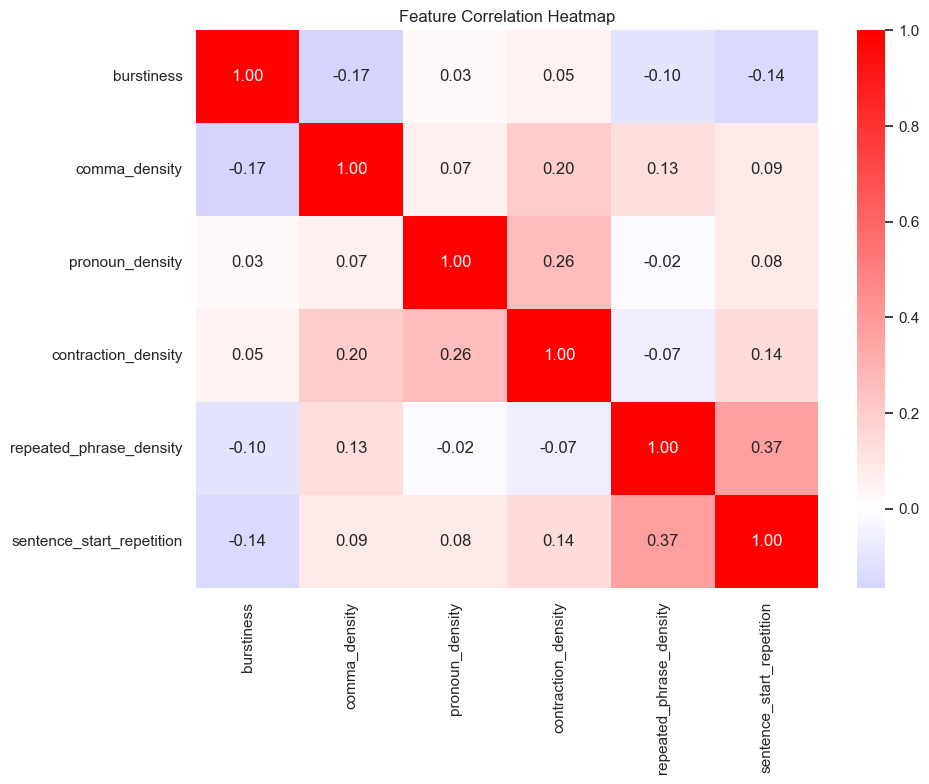

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df_balanced[['burstiness', 'comma_density', 'pronoun_density', 'contraction_density', 'repeated_phrase_density', 'sentence_start_repetition']].corr()
sb.heatmap(corr, annot=True, fmt='.2f', cmap='bwr', center=0, ax=ax)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


# Part 3: TF-IDF Vectorisation, Feature Fusion & Model Training

In this part we take the cleaned data and builds the machine learning pipeline. We decided to use TF-IDF as the main feature for our model. Feature fusion combines TF-IDF word vectors (3000 dimensions) with stylometric feature scores (5 dimensions) into a single 3005-dimensional input matrix. We also chose Logistic Regression to train our model.

### 3.1 Rationale for Using TF‑IDF Vectorization

The dataset is text which are words. Code cannot understand words like humans can. So we use TF-IDF as a means to assign vectorize the words in the dataset to make a statistical analysis.

TF‑IDF provides a simple yet effective representation of word usage patterns across a large corpus. Each essay is mapped to a sparse vector where common but uninformative words (e.g. “the”, “and”) are down‑weighted, while more distinctive terms that appear often in a few documents receive higher weights. This aligns well with our task: certain keywords such as “conclusion”, “important”, or “overall” show up disproportionately in AI essays, and TF‑IDF naturally emphasises these discriminative patterns.

Additionally, TF‑IDF is computationally efficient and easy to integrate with linear models on large datasets. We can cap the vocabulary to the top 3000 terms, yielding a high‑dimensional but sparse feature space that standard scikit‑learn implementations handle very well. Unlike more complex embeddings, TF‑IDF requires no pre‑training, no GPU, and is fully deterministic given our dataset.

Lastly, TF‑IDF combines nicely with our stylometric features. The TF‑IDF part captures “what” is being said (lexical content), while the stylometric features capture “how” it is written (style and structure). By stacking these two in a single feature matrix, we allow the classifier to learn interactions between specific words (e.g. “essay”, “important”) and style indicators (e.g. high repeated phrase density) that together signal AI usage.

### 3.2 Motivation for Choosing Logistic Regression

We evaluated multiple possible classifiers (e.g. decision trees, random forests) but ultimately selected logistic regression as our main model for three main reasons: interpretability, compatibility with sparse TF‑IDF features, and robustness on large, high‑dimensional text data.

**Interpretability and feature weights**

Logistic regression learns a linear decision boundary with a single weight for each feature, which directly tells us how much that feature pushes the prediction towards “AI” or “Human”. This matches our project goal: we do not only want a high‑accuracy detector, we also want to understand which stylometric statistics and words are most indicative of AI text. The top‑weight tables and bar charts (e.g. “important”, “essay”, and high repeated phrase density pushing towards AI) are easy to explain to a non‑technical audience and to relate back to our hypotheses.

Decision trees and random forests, while powerful, are much harder to interpret in this context. A tree splits on many thresholds across thousands of sparse features, and aggregating hundreds of trees into a forest makes it non‑trivial to answer simple questions like “which words are the strongest AI indicators?” Logistic regression, by contrast, provides a transparent ranking of features through its learned coefficients.

**Scalability with sparse TF‑IDF**

Our fused feature space combines 3000 TF‑IDF dimensions with 5 stylometric features, resulting in a very high‑dimensional but extremely sparse matrix. Logistic regression (with the scikit‑learn implementation) is optimised for exactly this. It uses efficient solvers on sparse matrices and scales well to hundreds of thousands of samples. Tree‑based models, especially random forests, tend to struggle with such wide sparse inputs because each split considers many features and often ends up splitting on noisy or rare terms; training becomes MUCH slower (might take days to train) and the risk of overfitting increases.

**Regularisation and generalisation**

Logistic regression supports L2 regularisation by default, which penalises large coefficients and helps the model generalise from our training essays to unseen text. In high‑dimensional text classification, regularisation is critical because many words are rare and could otherwise get extremely large weights if they happen to appear in a few training samples. The regularised logistic model finds a smoother boundary that depends on a broad set of features instead of memorising specific outliers.

In contrast, decision trees are high‑variance models that can overfit easily on noisy lexical features unless heavily pruned or combined in large ensembles. Random forests reduce variance via averaging but still produce complex, non‑linear boundaries that are harder to debug and tune in our setting. Given that linear models with TF‑IDF already perform strongly on text classification benchmarks, we chose logistic regression.

### 3.3 Overall Design Rationale: TF‑IDF + Stylometrics + Logistic Regression
Putting everything together, our design intentionally balances simplicity, interpretability, and performance.

TF‑IDF gives a high‑resolution view of word usage patterns, highlighting characteristic AI phrases and domain‑specific vocabulary.

Stylometric features summarise global properties of writing style (burstiness, punctuation usage, repetition, formality) that we hypothesised would differ between AI and humans.

Logistic regression acts as a linear, regularised classifier that can efficiently fuse thousands of TF‑IDF features with a small set of stylometric signals, while remaining easy to interpret through its learned weights and S‑curve probability output.

### 3.4 Explanation of the code

**Step 1 Train/Test Split (80/20)**  
Both the text column and the stylometric features are split together using the same random indices to maintain row alignment. 80% goes to training, 20% to unseen test evaluation.

**Step 2 TF-IDF Vectorisation (`max_features=3000`)**  
Converts raw text into a sparse matrix where each entry is the TF-IDF score of a word. TF-IDF rewards words that are frequent in a document but rare across the dataset. These are the words that best characterise AI vs human writing.  
 `fit_transform` on train set: learns vocabulary from training data only  
 `transform` on test set: applies the same vocabulary (prevents data leakage)

**Step 3 Standard Scaling for Stylometric Features**  
Rescales the 5 numerical stylometric features to zero mean and unit variance. Without this, raw stylometric values (e.g. burstiness can reach 50+) would numerically overwhelm the small TF-IDF values and distort the logistic regression weights.  
Same data-leakage rule: `fit_transform` on train, `transform` on test.

**Step 4 Feature Fusion with `scipy.sparse.hstack`**  
Horizontally stacks the sparse TF-IDF matrix and the dense scaled stylometric array side-by-side into one matrix of shape `(n_samples, 3005)`.

**Step 5 Logistic Regression (`max_iter=1000`)**  
Binary classifier trained on the fused feature matrix. Outputs a probability that each sample is AI-generated. `max_iter=1000` allows sufficient iterations for convergence on high-dimensional input.

**Step 6 Evaluation**  
Computes test accuracy and plots a Confusion Matrix showing: True Positives (AI correctly detected), True Negatives (Human correctly detected), False Positives, and False Negatives.

vectorizing text
scaling stylometric features
fusing features
training LR model

Test Data Accuracy: 0.9930


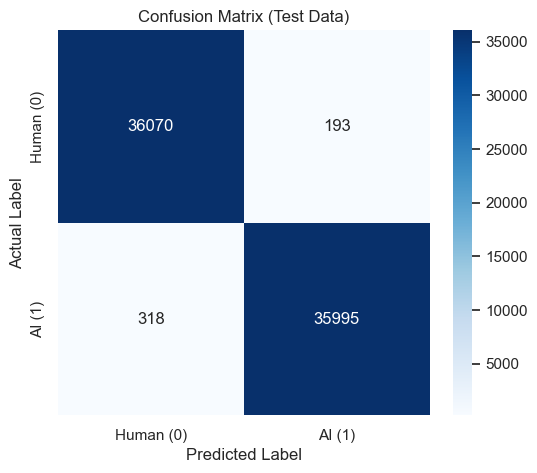

In [13]:
# 1. Train/Test Split
X_text = df_balanced['cleaned_text']
X_stats = df_balanced[['burstiness', 'comma_density', 'pronoun_density', 'contraction_density', 'repeated_phrase_density']]
y = df_balanced['generated']

X_text_train, X_text_test, X_stats_train, X_stats_test, y_train, y_test = train_test_split(X_text, X_stats, y, test_size=0.2)

# 2. TF-IDF Vectorization
print("vectorizing text")
tfidf = TfidfVectorizer(max_features=3000)
X_text_train_tfidf = tfidf.fit_transform(X_text_train)
X_text_test_tfidf = tfidf.transform(X_text_test) 

# 3. Scale Stylometric Features
print("scaling stylometric features")
scaler = StandardScaler()
X_stats_train_scaled = scaler.fit_transform(X_stats_train)
X_stats_test_scaled = scaler.transform(X_stats_test) 

# 4. Fuse Features together
print("fusing features")
X_train_final = sp.hstack([X_text_train_tfidf, X_stats_train_scaled])
X_test_final = sp.hstack([X_text_test_tfidf, X_stats_test_scaled])

# 5. Train Logistic Regression
print("training LR model")
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_final, y_train)

# 6. Evaluate
y_pred = log_reg.predict(X_test_final)
print(f"\nTest Data Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Human (0)', 'AI (1)'], 
            yticklabels=['Human (0)', 'AI (1)'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix (Test Data)')
plt.show()

## Part 4: Model Evaluation and Visualisation

Now we interpret the trained model's learned patterns and visualise its behaviour. Three deliverables are produced: feature weight tables, feature weight bar charts, and the logistic regression S-curve.

### 4.1 Checking for Top 15 Feature Weights

In logistic regression, each feature has a learned **coefficient (weight)**:
- **Large positive weight** = strong predictor of AI text (model pushes probability toward 1)
- **Large negative weight** = strong predictor of Human text (model pushes probability toward 0)
- **Near zero** = feature has little influence

So,we extract all 3005 weights (3000 TF-IDF word weights + 5 stylometric feature weights) and print the top/bottom 15.

In [15]:
# np.concatenate merges them into one
tfidf_feature_names = tfidf.get_feature_names_out()
stat_feature_names = ['burstiness', 'comma_density', 'pronoun_density', 'contraction_density', 'repeated_phrase_density']
all_feature_names = np.concatenate([tfidf_feature_names, stat_feature_names])

#Logistic Regression assigns a weight to each feature
#Positive wieghts push predictons toward AI-generated, Negative weights toward human-written
weights = log_reg.coef_[0]

#Sorts features by weight
feature_importance = pd.DataFrame({'Feature': all_feature_names, 'Weight': weights})
feature_importance = feature_importance.sort_values(by='Weight', ascending=False)

print("Top 15 Indicators of AI Text (+ Weights):")
print(feature_importance.head(15))

print("\nTop 15 Indicators of Human Text (- Weights):")
print(feature_importance.tail(15))

Top 15 Indicators of AI Text (+ Weights):
           Feature     Weight
1380     important  10.967478
2045     potential   9.378146
963          essay   9.223460
86    additionally   8.307720
1762          name   7.070309
590     conclusion   6.959222
173            and   6.757234
1813        number   6.742721
942         ensure   6.678226
2926           who   6.625798
2121       provide   6.415679
2031       popular   6.371792
774      difficult   6.340779
2281         risks   6.092564
607       consider   6.071320

Top 15 Indicators of Human Text (- Weights):
          Feature     Weight
2539     students  -6.122083
1212        going  -6.209045
2538  studentname  -6.307872
1764         nasa  -6.511314
1954       people  -6.513971
844       driving  -6.516927
141           all  -6.545111
891      electors  -6.941579
2873       voting  -7.181695
1643         many  -7.696638
1957      percent  -7.714552
1912    paragraph  -7.793750
153      although  -8.660128
2845         very  -8.8392

### 4.2 Top 15 Feature Weights (Bar Chart Visualisation)

The same feature weights are now presented as two side-by-side horizontal bar charts:
- **Left panel (orange):** Top 15 features most indicative of AI-generated text
- **Right panel (green):** Top 15 features most indicative of human-written text

Weights are **normalised to relative importance (0–1)** by dividing by the maximum absolute weight in each group, making both panels comparable on the same scale.

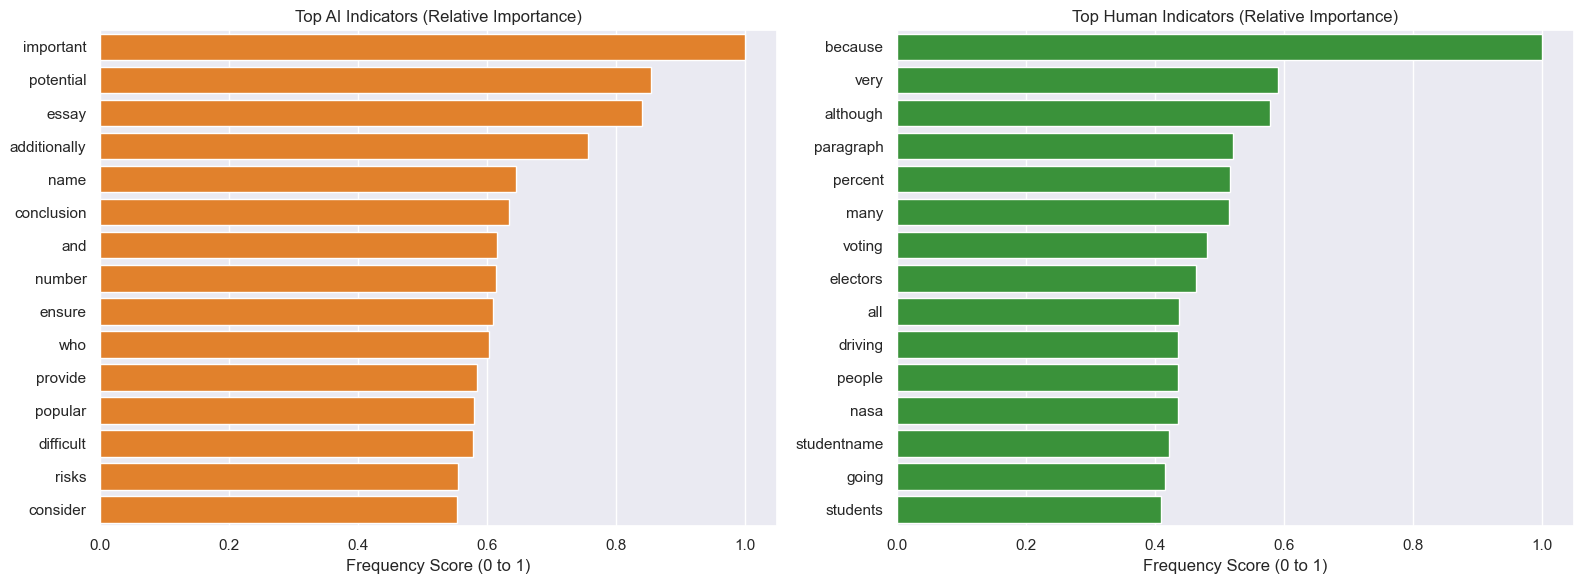

In [16]:
feature_importance = pd.DataFrame({'Feature': all_feature_names, 'Weight': weights})

#Sorts features by weight
top_ai_features = feature_importance.sort_values(by='Weight', ascending=False).head(15).copy()
top_human_features = feature_importance.sort_values(by='Weight', ascending=True).head(15).copy()

#Normalizes weights so they scale between 0 and 1
max_ai_weight = top_ai_features['Weight'].max()
max_human_weight = abs(top_human_features['Weight'].min())

top_ai_features['Relative_Importance'] = top_ai_features['Weight'] / max_ai_weight
top_human_features['Relative_Importance'] = abs(top_human_features['Weight']) / max_human_weight

#Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#AI Indicators
sb.barplot(data=top_ai_features, x='Relative_Importance', y='Feature', ax=axes[0], color='#ff7f0e')
axes[0].set_title('Top AI Indicators (Relative Importance)')
axes[0].set_xlabel('Frequency Score (0 to 1)')
axes[0].set_ylabel('')
axes[0].set_xlim(0, 1.05)

#Human Indicators
sb.barplot(data=top_human_features, x='Relative_Importance', y='Feature', ax=axes[1], color='#2ca02c')
axes[1].set_title('Top Human Indicators (Relative Importance)')
axes[1].set_xlabel('Frequency Score (0 to 1)')
axes[1].set_ylabel('')
axes[1].set_xlim(0, 1.05)

#Adjusts spacing to avoild overlapping before displaying the plots
plt.tight_layout()
plt.show()

### 4.3 Logistic Regression 

The S-curve in Logistic Regression (sigmoid function) visualises the model's **predicted probability of AI-generation** across all test samples, sorted from lowest to highest confidence.

- **Blue sigmoid line** = the model's AI probability prediction for each sample
- **Scattered dots** = actual labels (green = Human, orange = AI)
- **Red dashed line** = decision boundary at 0.5, samples above this are classified as AI, samples below this are classified as Human

A well-calibrated logistic regression produces a sharp S-shape: most human samples cluster near 0, most AI samples cluster near 1, with a clear transition crossing the 0.5 boundary. Misclassified samples appear as dots on the wrong side of the boundary line.


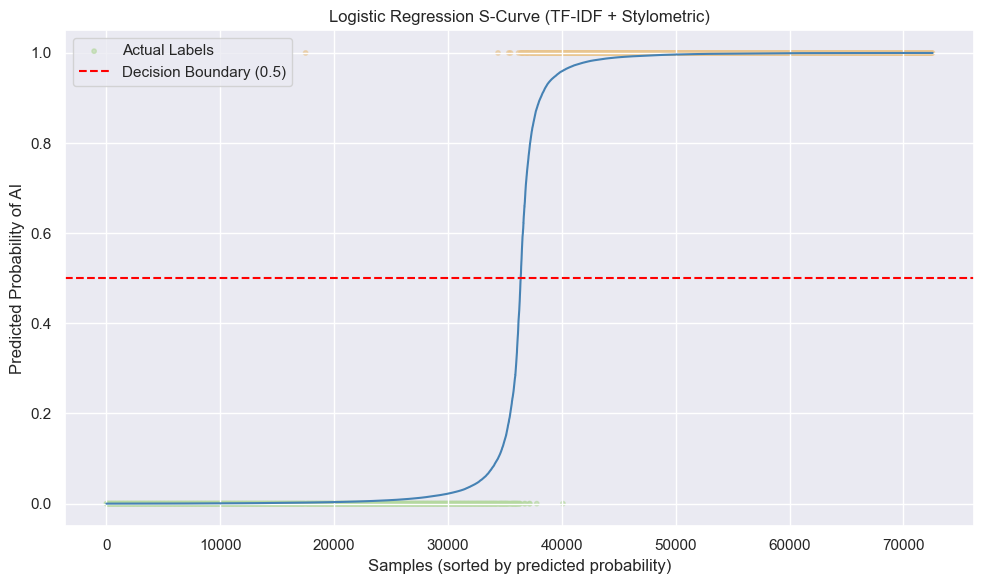

In [17]:
#predict_proba gives the probability of each class (0 or 1).
proba = log_reg.predict_proba(X_test_final)[:, 1]

#np.argsort returns indices that would sort the probabilities in ascending order.
sorted_idx = np.argsort(proba)

#y_test_sorted reorders the true labels according to those indices.
y_test_sorted = y_test.values[sorted_idx]

#proba_sorted is the sorted probabilities themselves.
proba_sorted = proba[sorted_idx]

# Sample every 50th point to reduce clutter
step = 50
sampled_x = range(0, len(proba), step)
sampled_y = y_test_sorted[::step]

# Creates plot
fig, ax = plt.subplots(figsize=(10, 6))

# The Dots (Actual Labels)
ax.scatter(sampled_x, sampled_y,
           c=['#b5d8a0' if y == 0 else '#e8c590' for y in sampled_y], 
           s=10, alpha=0.6, zorder=0, label='Actual Labels')

# S-Curve (The Predictions)
ax.plot(range(len(proba)), proba_sorted, color='steelblue', linewidth=1.5, zorder=1)

# Red Line (The Decision Boundary)
ax.axhline(y=0.5, color='red', linestyle='--', label='Decision Boundary (0.5)')

#Labels
ax.set_xlabel('Samples (sorted by predicted probability)')
ax.set_ylabel('Predicted Probability of AI')
ax.set_title('Logistic Regression S-Curve (TF-IDF + Stylometric)')
ax.legend()

#Adjusts spacing before displaying the plot
plt.tight_layout()
plt.show()


## Part 5: AI Essays Detector

We created a demo detector using our trained model where the user can input any essay they want to check if the probability of it either being AI generated or Human generated.

**How it works:**
1. Prompts the user to paste any piece of text.
2. Cleans the input using `clean_text`.
3. Computes all 5 stylometric scores.
4. Vectorises the text with the trained TF-IDF model and scales stylometric features with the trained scaler.
5. Stacks into a fused feature vector and passes to the trained logistic regression.
6. Outputs the classification (Human/AI) and confidence probabilities for both classes.

In [18]:
# User Input

def detect_ai_text():
    print("="*50)
    print("AI ESSAYS DETECTOR")
    print("="*50)
    
    user_input_text = input("Paste your text here:\n> ")
    
    if len(user_input_text.strip()) == 0:
        print("\nNo text detected! Please run the cell again.")
        return
        
# Feature Engineering   
    
    cleaned = clean_text(user_input_text)
    
    burst = get_burstiness(cleaned)
    comma_den = get_comma_density(cleaned)
    pronoun_den = get_personal_pronoun_density(cleaned)
    contraction_den = get_contraction_density(cleaned)
    repeat_phrase = get_repeated_phrase_density(cleaned)
    
    user_stats = pd.DataFrame(
        [[burst, comma_den, pronoun_den, contraction_den, repeat_phrase]], 
        columns=['burstiness', 'comma_density', 'pronoun_density', 'contraction_density', 'repeated_phrase_density']
                            )
#Combining TF-IDF word data and stylometric features   
    
    scaled_stats = scaler.transform(user_stats)
    tfidf_text = tfidf.transform([cleaned]) 
    final_input = sp.hstack([tfidf_text, scaled_stats])

#Prediction in Logistic Regression model
    
    prediction = log_reg.predict(final_input)[0]
    probabilities = log_reg.predict_proba(final_input)[0]
    
    print("\n" + "-" * 40)
    print("ANALYSIS RESULTS")
    print("-" * 40)
    print(f"Burstiness Score: {burst:.2f}")
    print(f"Comma Density: {comma_den:.2f}")
    print(f"Pronoun Density: {pronoun_den:.2f}")
    print(f"Contraction Density: {contraction_den:.2f}")
    print(f"Repeated Phrase Density: {repeat_phrase:.2f}")
    print("-" * 40)
    
    if prediction == 1:
        print("AI GENERATED")
    else:
        print("HUMAN GENERATED")
        
    print(f"Confidence it is AI: {probabilities[1]*100:.2f}%")
    print(f"Confidence it is Human: {probabilities[0]*100:.2f}%")
    print("="*50 + "\n")

detect_ai_text()

AI ESSAYS DETECTOR


Paste your text here:
>  The Pope flew back to Rome last night after a unique "pastoral" visit to Cuba, the political consequences of which will continue to be analysed for a long time to come.  Though he stressed in yesterday's homily at the fourth and final open-air mass in Havana that the church did not seek political power, there is little doubt that the visit has substantially enhanced the church's traditionally marginal role in Cuban society.  Hundreds of thousands of people packed the historic Plaza de la Revolucion, interrupting the Pope with chanting and applause as he told them that the "spirit of the Lord" had sent him to "proclaim the release of captives and liberty to the oppressed".  His speech, which included calls for change in the Cuban political system and criticism of the prevailing capitalist alternatives, was greeted by President Fidel Castro - seated in the front row - with apparent equanimity.  But there was no doubting the strong desire for change among large se


----------------------------------------
ANALYSIS RESULTS
----------------------------------------
Burstiness Score: 9.95
Comma Density: 5.22
Pronoun Density: 0.31
Contraction Density: 0.92
Repeated Phrase Density: 1.23
----------------------------------------
HUMAN GENERATED
Confidence it is AI: 29.70%
Confidence it is Human: 70.30%




## Our AI Essays Detector Website

Similar to the demo code above, we created a working website with clean UI to easily visualise and use our AI Essays Detector.

#### Link: https://ai-essays-detector.onrender.com/

Disclaimer: The website might take a 1 or 2 minutes to load as it times our after 15 minutes of inactivity. Cons of using Render free account.

## References

- Code Basics. (2022, August 17). Understanding TF‑IDF and logistic regression [Video]. YouTube. https://www.youtube.com/watch?v=ATK6fm3cYfI

- GeeksforGeeks. (2025, December 17). Understanding TF-IDF (Term Frequency–Inverse Document Frequency). https://www.geeksforgeeks.org/machine-learning/understanding-tf-idf-term-frequency-inverse-document-frequency/

- GeeksforGeeks. (2026, April 6). Understanding logistic regression. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/understanding-logistic-regression/

- Kannan, P. (2023, March 16). Was this written by a human or AI?. Stanford HAI. https://hai.stanford.edu/news/was-written-human-or-ai-tsu
Visually Explained. (2025, June 2). Logistic Regression (and why it’s different from Linear Regression). YouTube. https://www.youtube.com/watch?v=3bvM3NyMiE0

- Wikipedia . (2019, April 12). Logistic Regression. Wikipedia; Wikimedia Foundation. https://en.wikipedia.org/wiki/Logistic_regression

